# Bases and reference measures

How a function becomes a vector, and what the base measure is doing while that happens.
```{note}
Tiny on purpose — a couple dozen modes, a couple thousand steps, a minute or two on a CPU. It's
here to show the API, not to be impressive. Real ones live in `FuncyFlows/examples/`.
```

## A basis is just a design matrix

Evaluate a basis at some points and you get `[num_points, num_functions]` with orthonormal columns. After that it's linear algebra on the coefficient side and you can mostly forget there was a function involved.

In [1]:
import matplotlib.pyplot as plt
import torch

from FuncyFlows.base_measures import CosineBasis, FourierBasis, GaussianReferenceMeasure

torch.manual_seed(0)
DTYPE = torch.float64
M, GRID = 32, 400

basis = CosineBasis(M, dtype=DTYPE)
points = torch.linspace(0, 1, GRID, dtype=DTYPE)[:, None]
design = basis.evaluate(points)                 # [GRID, M]
print("design:", tuple(design.shape))
print("orthonormal? max |Phi^T Phi / GRID - I| =",
      ((design.T @ design / GRID) - torch.eye(M, dtype=DTYPE)).abs().max().item())

design: (400, 32)
orthonormal? max |Phi^T Phi / GRID - I| = 0.005000000000000901


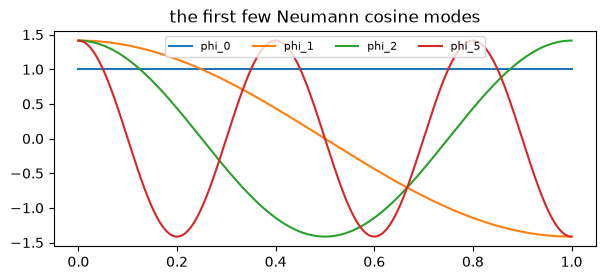

In [2]:
fig, ax = plt.subplots(figsize=(7, 2.8))
for k in (0, 1, 2, 5):
    ax.plot(points[:, 0], design[:, k], label=f"phi_{k}")
ax.legend(ncol=4, fontsize=8)
ax.set_title("the first few Neumann cosine modes")
plt.show()

## Projection, and what truncation costs you

Project onto `M` modes, reconstruct, look at the error. Do this before you blame a model for failing at something the basis was never able to represent — it'll save you a day.

In [3]:
def project(values, design):
    """Values on a uniform grid -> coefficients, by the rectangle rule."""
    return values @ design / design.shape[0]

target = torch.exp(-((points[:, 0] - 0.35) / 0.05) ** 2)      # a narrow bump
for modes in (8, 16, 32):
    small = CosineBasis(modes, dtype=DTYPE)
    small_design = small.evaluate(points)
    recon = project(target[None], small_design) @ small_design.T
    print(f"M={modes:3d}  relative L2 error {(recon[0] - target).norm() / target.norm():.3f}")

M=  8  relative L2 error 0.512
M= 16  relative L2 error 0.114
M= 32  relative L2 error 0.003


## The reference measure

`GaussianReferenceMeasure` is `N(0, diag(sigma^2))` on the coefficients. Two ways in: a smoothness prior `sigma_k^2 = (1 + alpha * lambda_k)^-p`, or hand it per-mode variances yourself. Bigger `power` means smoother draws, and you can see it immediately.

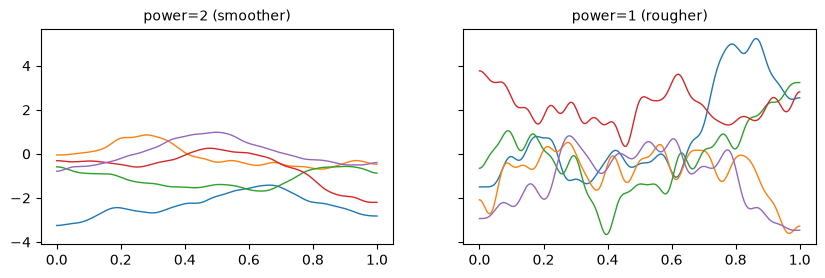

first five standard deviations, power=2: [1.0, 0.6695769964489584, 0.336256423851713, 0.18377886910303912, 0.1124140711226688]


In [4]:
smooth = GaussianReferenceMeasure(basis, alpha=0.05, power=2.0, dtype=DTYPE)
rough  = GaussianReferenceMeasure(basis, alpha=0.05, power=1.0, dtype=DTYPE)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8), sharey=True)
for ax, (name, measure) in zip(axes, [("power=2 (smoother)", smooth), ("power=1 (rougher)", rough)]):
    ax.plot(points[:, 0], (measure.sample(5) @ design.T).T, lw=1)
    ax.set_title(name, fontsize=10)
plt.show()

print("first five standard deviations, power=2:", smooth.scale[:5].tolist())

## Getting the measure from data

Usually you don't pick the variances, you fit them to a bank of examples. That diagonal Gaussian then does double duty: it's the flow's base measure *and* it's the 'GP that already knows the bank' baseline you'll be trying to beat later.

In [5]:
bank = smooth.sample(2000)
data_measure = GaussianReferenceMeasure(basis, variances=bank.var(0).clamp(min=1e-12))
print("recovered variances match to",
      (data_measure.variances / smooth.variances - 1).abs().max().item())

recovered variances match to 0.060052331562939765


## 2D is the same thing

Pass `physical_dim=2`. Columns are still sorted by Laplacian eigenvalue, so truncating still keeps the smooth end.

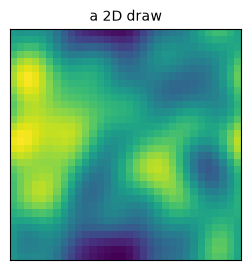

In [6]:
basis2d = FourierBasis(64, physical_dim=2, dtype=DTYPE)
axis = (torch.arange(32, dtype=DTYPE) + 0.5) / 32
grid = torch.cartesian_prod(axis, axis)
field = (GaussianReferenceMeasure(basis2d, alpha=0.02, power=2.0).sample(1)
         @ basis2d.evaluate(grid).T)
plt.figure(figsize=(3, 3))
plt.imshow(field.reshape(32, 32).T, origin="lower")
plt.xticks([]); plt.yticks([]); plt.title("a 2D draw", fontsize=10)
plt.show()

---

Next up: [fitting a prior to samples](02_learn_a_prior.ipynb).